In [ ]:
%load_ext autoreload
%autoreload 2

from plonk.pipe import PlonkPipeline
from PIL import Image
from pathlib import Path
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize


device = torch.device("cuda")

/home/charles/miniforge3/envs/plonk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
pipeline = PlonkPipeline("local_models/StreetCLIP_Multi_Mean_Model").to(device)

Loading weights from local directory


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 63109.86it/s]
CLIPVisionModel LOAD REPORT from: geolocal/StreetCLIP
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED | 

Using a specific image

In [16]:
image_path = "demo/examples/santa_clara.jpg"
output_path = "demo/results/santa_clara.pdf"
image = Image.open(image_path)

In [17]:
gps_coords = pipeline(image, batch_size=1024)

/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


In [18]:
latitude, longitude, likelihood = pipeline.compute_likelihood_grid(image, grid_resolution_deg=1, batch_size=4096, cfg=0)

Computing likelihood over a 181x361 grid (65341 points)...


Computing Likelihood Grid:   0%|          | 0/16 [00:00<?, ?it/s]

Computing Likelihood Grid:   6%|▋         | 1/16 [00:44<11:06, 44.41s/it]

Likelihood NFE: 1154


Computing Likelihood Grid:  12%|█▎        | 2/16 [01:26<10:04, 43.21s/it]

...

Likelihood NFE: 1166


Computing Likelihood Grid:  94%|█████████▍| 15/16 [12:01<00:45, 45.55s/it]

Likelihood NFE: 1088


Computing Likelihood Grid: 100%|██████████| 16/16 [12:38<00:00, 47.39s/it]

Likelihood NFE: 1010


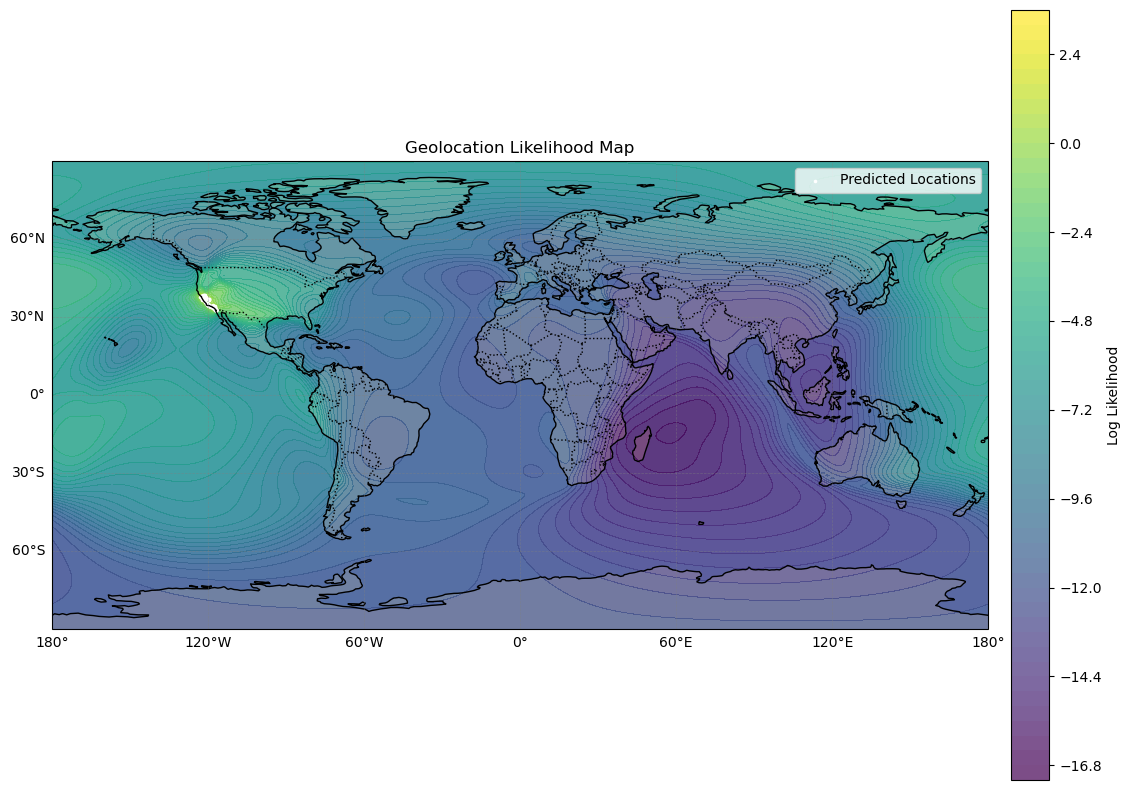

In [21]:
# Create a figure with a map projection
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Create a mesh grid for the contour plot
lon_mesh, lat_mesh = np.meshgrid(longitude, latitude)

# Normalize the likelihood values for better visualization
# Higher values should be more prominent
norm = Normalize(vmin=likelihood.min(), vmax=likelihood.max())

# Create a filled contour plot of the likelihood values
contour = ax.contourf(lon_mesh, lat_mesh, likelihood, 
                      transform=ccrs.PlateCarree(),
                      cmap='viridis', norm=norm, levels=50, alpha=0.7)

# Add a colorbar
cbar = plt.colorbar(contour, ax=ax, orientation='vertical', pad=0.02)
cbar.set_label('Log Likelihood')

# Mark the predicted GPS coordinates
ax.scatter(gps_coords[:, 1], gps_coords[:, 0], 
           color='white', marker='.', s=10, 
           transform=ccrs.PlateCarree(), 
           label='Predicted Locations')

# Add gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False

# Add title and legend
plt.title('Geolocation Likelihood Map')
plt.legend()

# Show the plot
plt.tight_layout()
plt.savefig(output_path)
plt.show()


In [20]:
# Compute localizability
localizability = pipeline.compute_localizability(image)
print(f"Localizability: {localizability}")

/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


Likelihood NFE: 518
Localizability: 1.0145138502120972


Using Multiple Images combination

In [ ]:
image_dir = "proximity_batches/batch_4"
output_path = "demo/results/"
entries = [[Image.open(p) for p in sorted(Path(image_dir).glob("*.jpg"))]]

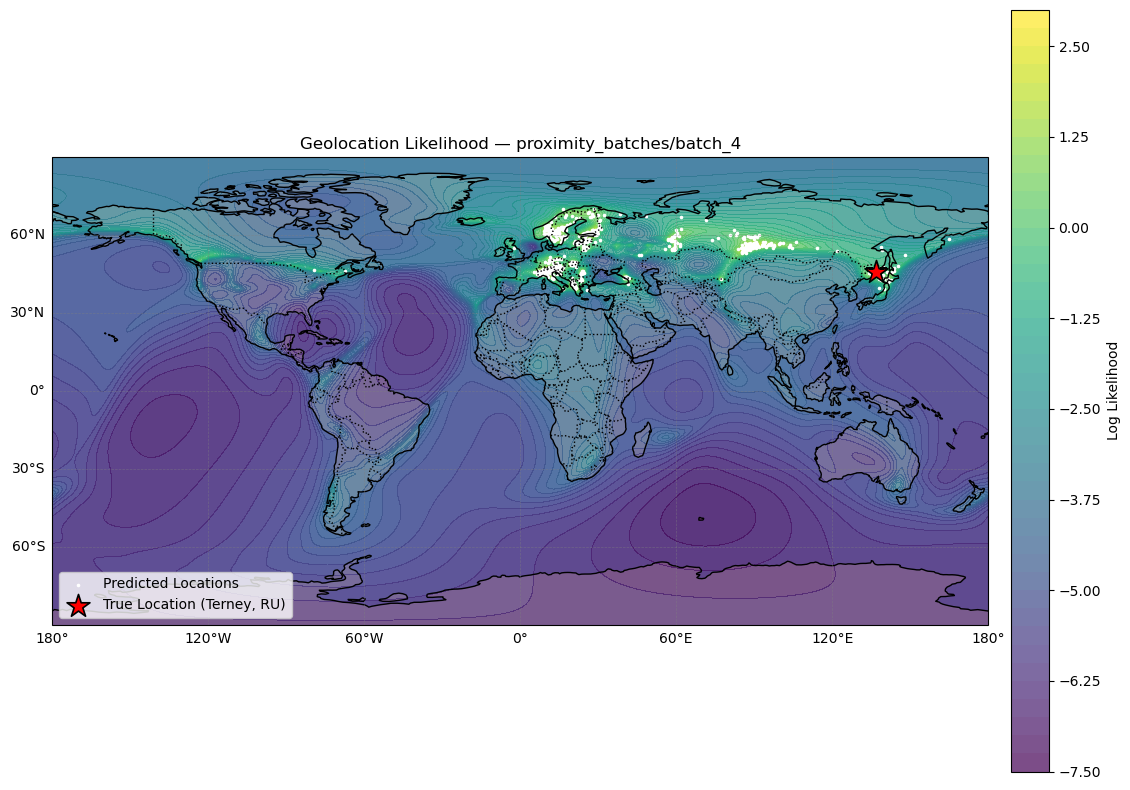

In [ ]:
with open(Path(image_dir) / "anchor_location.json") as f:
    truth = json.load(f)
true_lat, true_lon = truth["latitude"], truth["longitude"]

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

lon_mesh, lat_mesh = np.meshgrid(longitude, latitude)
norm = Normalize(vmin=likelihood.min(), vmax=likelihood.max())
contour = ax.contourf(lon_mesh, lat_mesh, likelihood,
                      transform=ccrs.PlateCarree(),
                      cmap="viridis", norm=norm, levels=50, alpha=0.7)
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Log Likelihood")

ax.scatter(gps_coords[:, 1], gps_coords[:, 0],
           color="white", marker=".", s=10,
           transform=ccrs.PlateCarree(),
           label="Predicted Locations")

ax.scatter([true_lon], [true_lat],
           color="red", marker="*", s=300, edgecolor="black", linewidth=1.2,
           transform=ccrs.PlateCarree(), zorder=5,
           label=f"True Location ({truth.get('city','')}, {truth.get('country','')})")

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

plt.title(f"Geolocation Likelihood — {image_dir}")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()


/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


Computing likelihood over a 181x361 grid (65341 points)...


Computing Likelihood Grid:   6%|▋         | 1/16 [00:50<12:38, 50.54s/it]

Likelihood NFE: 1346


Computing Likelihood Grid:  12%|█▎        | 2/16 [01:37<11:20, 48.60s/it]

...

Likelihood NFE: 1250


Computing Likelihood Grid:  94%|█████████▍| 15/16 [12:37<00:47, 47.00s/it]

Likelihood NFE: 1100


Computing Likelihood Grid: 100%|██████████| 16/16 [13:11<00:00, 49.50s/it]

Likelihood NFE: 974


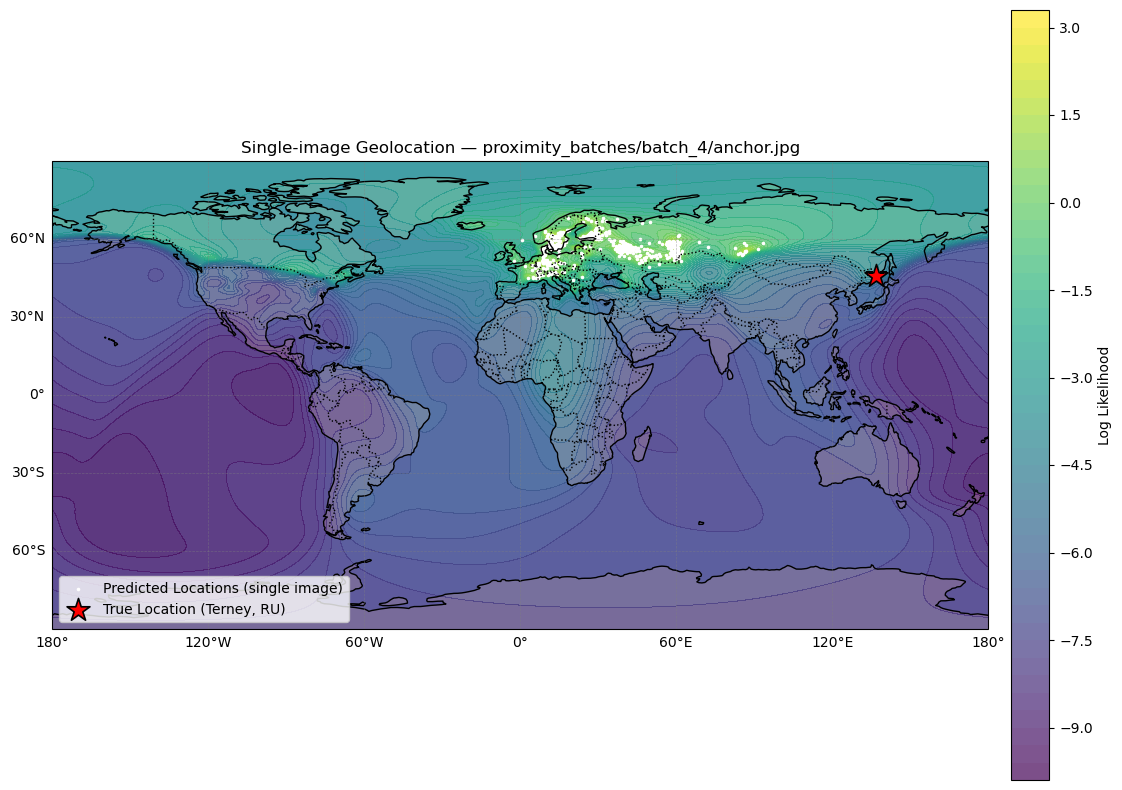

In [ ]:
# Single-image baseline: run the pipeline on just the anchor image
single_image = Image.open(Path(image_dir) / "anchor.jpg")

single_gps = pipeline(single_image, batch_size=1024)
single_lat, single_lon, single_likelihood = pipeline.compute_likelihood_grid(
    single_image, grid_resolution_deg=1, batch_size=4096, cfg=0
)

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")

lon_mesh, lat_mesh = np.meshgrid(single_lon, single_lat)
norm = Normalize(vmin=single_likelihood.min(), vmax=single_likelihood.max())
contour = ax.contourf(lon_mesh, lat_mesh, single_likelihood,
                      transform=ccrs.PlateCarree(),
                      cmap="viridis", norm=norm, levels=50, alpha=0.7)
cbar = plt.colorbar(contour, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Log Likelihood")

ax.scatter(single_gps[:, 1], single_gps[:, 0],
           color="white", marker=".", s=10,
           transform=ccrs.PlateCarree(),
           label="Predicted Locations (single image)")

ax.scatter([true_lon], [true_lat],
           color="red", marker="*", s=300, edgecolor="black", linewidth=1.2,
           transform=ccrs.PlateCarree(), zorder=5,
           label=f"True Location ({truth.get('city','')}, {truth.get('country','')})")

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

plt.title(f"Single-image Geolocation — {image_dir}/anchor.jpg")
plt.legend(loc="lower left")
plt.tight_layout()
plt.show()
plt.savefig("demo/results/anchor_only.pdf")

Save Video of evolution of model predictions from randomness

In [55]:
image_path = "demo/examples/beacon_hill.png"
image_out = "beacon_hill"
image = Image.open(image_path)

FileNotFoundError: [Errno 2] No such file or directory: 'demo/examples/beacon_hill.png'

/home/charles/code/EECE5639_Final_Project_Fork/plonk/models/samplers/riemannian_flow_sampler.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=dtype):


NameError: name 'image_out' is not defined

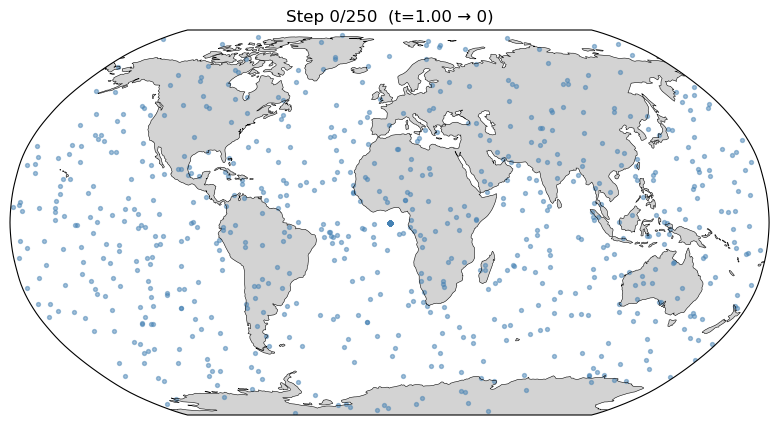

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.animation import FuncAnimation

_, traj = pipeline(image, batch_size=1024, return_trajectories=True)

# num_frames = 10
# frame_indices = np.linspace(0, len(traj) - 1, num_frames, dtype=int)
frame_indices = np.arange(len(traj))
num_frames = len(frame_indices)
frames = [traj[i] for i in frame_indices]

fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.4)
ax.set_global()

scatter = ax.scatter([], [], s=8, color="steelblue", alpha=0.5,
                     transform=ccrs.PlateCarree())
title = ax.set_title("")

def update(i):
    pts = frames[i]
    scatter.set_offsets(np.c_[pts[:, 1], pts[:, 0]])
    step = frame_indices[i]
    title.set_text(f"Step {step}/{len(traj)-1}  (t={1 - step/(len(traj)-1):.2f} → 0)")
    return scatter, title

ani = FuncAnimation(fig, update, frames=num_frames, interval=600, blit=False)
ani.save(f"demo/diagrams/{image_out}_diffusion_trajectory.mp4", writer="ffmpeg", fps=12, dpi=150)
plt.close()
print("Saved to diffusion_trajectory.mp4")